In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pprint import pprint
from sklearn.utils import resample

sns.set_style("whitegrid")

In [2]:
#_____TASK 1_____

In [3]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

print(X.head())
print(f"\nFeature Names: {X.columns}")
print(f"\nTarget (median house value in $100k): {y[:5]}")
print(f"\nDataset shape: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print("-" * 30)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R^2): {r2:.4f}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Feature Names: Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

Target (median house value in $100k): 0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

Dataset shape: (20640, 8)

Model Evaluation Metrics:
------------------------------
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
Mean Absolute Err




 
*The model achieved an R^2 value of **0.5758**, which means that approximately 57.58% of the variance in the target variable is explained by the input features.*

*The model captures more than half of the underlying patterns in the data.
However, about **42.42%** of the variance remains unexplained, suggesting that there may be other important factors or nonlinear relationships not captured by the model.*

*In practice, this means the model has reasonable predictive ability, but there is still room for improvement—such as adding more relevant features.*

In [4]:
#_____TASK 2_____

Ridge Regression Results (Test R^2):
----------------------------------------
Alpha = 0.01   | R^2 = 0.57578799
Alpha = 0.1    | R^2 = 0.57579052
Alpha = 1      | R^2 = 0.57581574
Alpha = 10     | R^2 = 0.57605990
Alpha = 100    | R^2 = 0.57779128

Lasso Regression Results (Test R^2):
----------------------------------------
Alpha = 0.01   | R^2 = 0.58161543
Alpha = 0.1    | R^2 = 0.48136113
Alpha = 1      | R^2 = -0.00021909
Alpha = 10     | R^2 = -0.00021909
Alpha = 100    | R^2 = -0.00021909


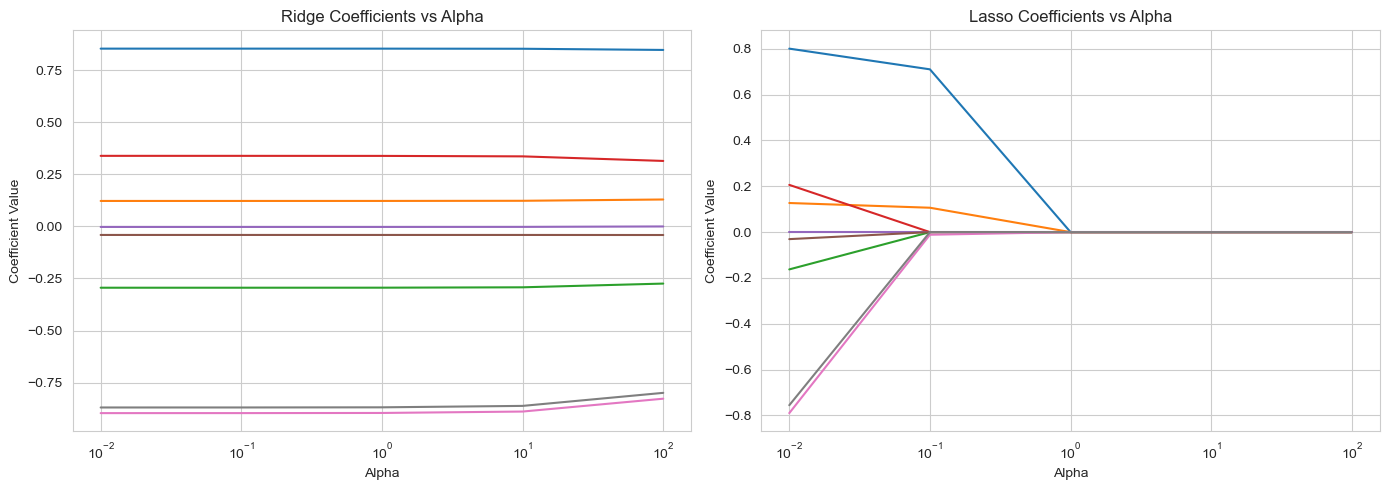

            Model  Best Alpha  R² Score
0             OLS         NaN -0.000219
1  Ridge (best α)      100.00  0.577791
2  Lasso (best α)        0.01  0.581615


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

alphas = [0.01, 0.1, 1, 10, 100]

ridge_coefs = []
lasso_coefs = []

results = {}

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    results[alpha] = r2
    ridge_coefs.append(ridge.coef_)

print("Ridge Regression Results (Test R^2):")
print("-" * 40)
for alpha, score in results.items():
    print(f"Alpha = {alpha:<6} | R^2 = {score:.8f}")

results_lasso = {}

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    results_lasso[alpha] = r2
    lasso_coefs.append(lasso.coef_)

print("\nLasso Regression Results (Test R^2):")
print("-" * 40)
for alpha, score in results_lasso.items():
    print(f"Alpha = {alpha:<6} | R^2 = {score:.8f}")

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(ridge_coefs.shape[1]):
    axes[0].plot(alphas, ridge_coefs[:, i], label=f'Feature {i}')
axes[0].set_xscale('log')
axes[0].set_title('Ridge Coefficients vs Alpha')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Coefficient Value')

for i in range(lasso_coefs.shape[1]):
    axes[1].plot(alphas, lasso_coefs[:, i], label=f'Feature {i}')
axes[1].set_xscale('log')
axes[1].set_title('Lasso Coefficients vs Alpha')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Coefficient Value')

plt.tight_layout()
plt.show()

best_ridge_alpha = max(results, key=results.get)
best_lasso_alpha = max(results_lasso, key=results_lasso.get)

best_ridge_r2 = results[best_ridge_alpha]
best_lasso_r2 = results_lasso[best_lasso_alpha]

ols_r2 = r2

comparison = pd.DataFrame({
    "Model": ["OLS", "Ridge (best α)", "Lasso (best α)"],
    "Best Alpha": [None, best_ridge_alpha, best_lasso_alpha],
    "R² Score": [ols_r2, best_ridge_r2, best_lasso_r2]
})

print(comparison)

*As alpha increases, both models shrink the size of the coefficients to simplify the model. In the Ridge plot, the lines get closer to zero very slowly but never actually touch it. However, in the Lasso plot, the coefficients drop quickly and hit exactly zero, which removes those features from the model. The features represented by the **purple, brown, and orange** lines are the first to be zeroed out because they have the smallest impact.*

*Feature scaling is especially important for regularized models such as Ridge and Lasso regression because these models add a penalty term to the loss function based on the magnitude of the coefficients.*

In [6]:
#_____TASK 3_____

In [7]:
svr_model = SVR(kernel='linear')

svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

svr_r2 = r2_score(y_test, y_pred_svr)

print("\nSupport Vector Regression (Linear Kernel) Results:")
print("-" * 50)
print(f"Test R^2 Score: {svr_r2:.8f}")

C_values = [0.1, 1, 10]
epsilon_values = [0.1, 0.2]

results1 = {}

best_score = -np.inf
best_params = None

for C in C_values:
    for eps in epsilon_values:
        svr = SVR(kernel='rbf', C=C, epsilon=eps)
        svr.fit(X_train_scaled, y_train)
        
        y_pred = svr.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)
        
        results1[(C, eps)] = r2
        
        print(f"C={C:<4} | epsilon={eps:<3} | R^2={r2:.4f}")
        
        if r2 > best_score:
            best_score = r2
            best_params = (C, eps)

print("\nBest SVR (RBF) Configuration:")
print("-" * 40)
print(f"C = {best_params[0]}")
print(f"epsilon = {best_params[1]}")
print(f"Best Test R^2 = {best_score:.4f}")

X_train_sample, y_train_sample = resample(
    X_train_scaled,
    y_train,
    n_samples=5000,
    random_state=42
)

results2 = {}

svr_rbf = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_rbf.fit(X_train_sample, y_train_sample)
results2["RBF"] = r2_score(y_test, svr_rbf.predict(X_test_scaled))

svr_poly2 = SVR(kernel='poly', degree=2, C=10, epsilon=0.1)
svr_poly2.fit(X_train_sample, y_train_sample)
results2["Poly (deg=2)"] = r2_score(y_test, svr_poly2.predict(X_test_scaled))

svr_poly3 = SVR(kernel='poly', degree=3, C=10, epsilon=0.1)
svr_poly3.fit(X_train_sample, y_train_sample)
results2["Poly (deg=3)"] = r2_score(y_test, svr_poly3.predict(X_test_scaled))

print("\nSVR Kernel Comparison (Subsampled Training, Test R²):")
print("-" * 55)
for model, score in results2.items():
    print(f"{model:<15} | R^2 = {score:.4f}")


Support Vector Regression (Linear Kernel) Results:
--------------------------------------------------
Test R^2 Score: 0.55794988
C=0.1  | epsilon=0.1 | R^2=0.6822
C=0.1  | epsilon=0.2 | R^2=0.6838
C=1    | epsilon=0.1 | R^2=0.7276
C=1    | epsilon=0.2 | R^2=0.7290
C=10   | epsilon=0.1 | R^2=0.7530
C=10   | epsilon=0.2 | R^2=0.7548

Best SVR (RBF) Configuration:
----------------------------------------
C = 10
epsilon = 0.2
Best Test R^2 = 0.7548

SVR Kernel Comparison (Subsampled Training, Test R²):
-------------------------------------------------------
RBF             | R^2 = 0.7337
Poly (deg=2)    | R^2 = -1.6675
Poly (deg=3)    | R^2 = -238.4211


*SVR performs better than the simple linear models. Linear SVR gives an R^2 of about **0.56**, which is close to OLS and Ridge, so it does not add much benefit in the linear case. However, RBF SVR improves performance a lot, reaching about **0.75** R^2, which is clearly higher than the linear models. This shows that the extra complexity of SVR is only justified when using a non-linear kernel like RBF, not for linear SVR.*


In [8]:
#_____TASK 4_____

                       MSE      RMSE       MAE        R²
LinearRegression  0.555892  0.745581  0.533200  0.575788
Ridge (best)      0.553266  0.743819  0.533014  0.577791
Lasso (best)      0.548255  0.740442  0.535326  0.581615
SVR (RBF best)    0.321273  0.566809  0.379624  0.754830


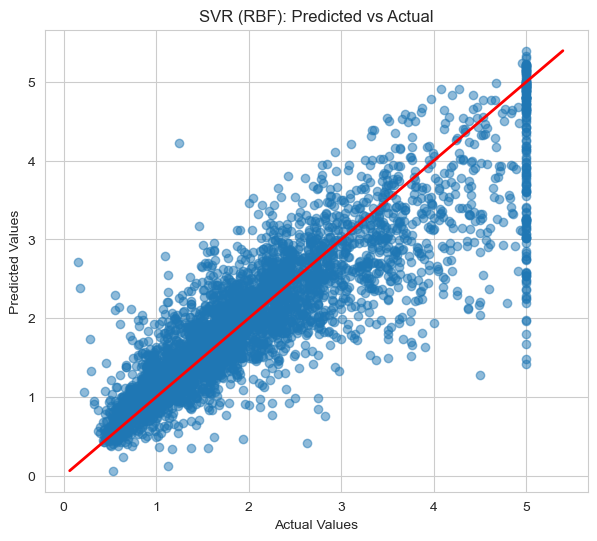

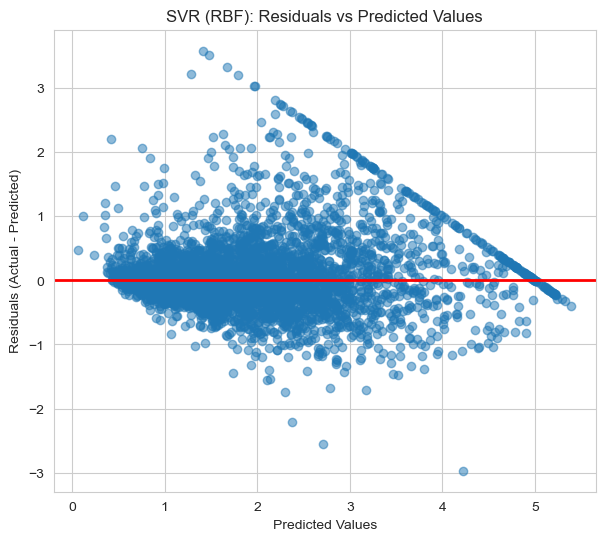

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

ols_pred = model.predict(X_test)

best_ridge = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_train_scaled, y_train)
ridge_pred = best_ridge.predict(X_test_scaled)

best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)
lasso_pred = best_lasso.predict(X_test_scaled)

svr_best = SVR(kernel='rbf', C=10, epsilon=0.2)
svr_best.fit(X_train_scaled, y_train)
svr_pred = svr_best.predict(X_test_scaled)

def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

results = {
    "LinearRegression": get_metrics(y_test, ols_pred),
    "Ridge (best)": get_metrics(y_test, ridge_pred),
    "Lasso (best)": get_metrics(y_test, lasso_pred),
    "SVR (RBF best)": get_metrics(y_test, svr_pred),
}

df_results = pd.DataFrame(results, index=["MSE", "RMSE", "MAE", "R²"]).T

print(df_results)

svr_best = SVR(kernel='rbf', C=10, epsilon=0.2)
svr_best.fit(X_train_scaled, y_train)

y_pred_best = svr_best.predict(X_test_scaled)

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred_best, alpha=0.5)

min_val = min(min(y_test), min(y_pred_best))
max_val = max(max(y_test), max(y_pred_best))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR (RBF): Predicted vs Actual")

plt.grid(True)
plt.show()

svr_best = SVR(kernel='rbf', C=10, epsilon=0.2)
svr_best.fit(X_train_scaled, y_train)

y_pred_best = svr_best.predict(X_test_scaled)

residuals = y_test - y_pred_best

plt.figure(figsize=(7, 6))

plt.scatter(y_pred_best, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linewidth=2)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("SVR (RBF): Residuals vs Predicted Values")

plt.grid(True)
plt.show()

***Final Evaluation and Conclusion***

*Based on the provided metrics and charts, the SVR (RBF best) model clearly performs the best among all candidates. It achieves the highest $R^2$ score of 0.7548 and the lowest error values across MSE, RMSE, and MAE. While the linear models (Linear, Ridge, and Lasso) show very similar results, they fail to capture the complex patterns that the SVR model handles effectively.However, there is a clear trade-off between model complexity and computational performance. SVR with an RBF kernel is more mathematically complex and requires more time to train and tune compared to a simple Linear Regression. In the "Predicted vs Actual" plot, we can see that even the best model struggles with high values, visible as a vertical line of points at the value of 5.If I were to deploy one of these models, I would choose the SVR (RBF best) because its superior accuracy justifies the extra complexity. The significant jump in $R^2$ from approximately 0.58 to 0.75 suggests that the underlying data is non-linear. Even though linear models are faster, the SVR provides a much more reliable prediction for the user.*